In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
dhaka = pd.read_csv('Dhaka_Dataset.csv')

In [ ]:
dhaka = dhaka.drop(columns=['name','stations','icon','sunset','sunrise','severerisk','snow','snowdepth','description'])
dhaka = dhaka.drop(dhaka.index[-1])

In [ ]:
dhaka['preciptype'].fillna("no rain", inplace=True)

In [ ]:
def get_month(A):
    m = int(A[3:5])
    if (m == 1):
        return 'January'
    elif (m == 2):
        return 'February'
    elif (m == 3):
        return 'March'
    elif (m == 4):
        return 'April'
    elif (m == 5):
        return 'May'
    elif (m == 6):
        return 'June'
    elif (m == 7):
        return 'July'
    elif (m == 8):
        return 'August'
    elif (m == 9):
        return 'September'
    elif (m == 1):
        return 'October'
    elif (m == 11):
        return 'November'
    elif (m == 12):
        return 'December'
    else:
        return 'Unknown'

In [ ]:
dhaka['month'] = dhaka['datetime'].apply(get_month)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
dhaka['preciptype']= le.fit_transform(dhaka['preciptype'])
dhaka['conditions']= le.fit_transform(dhaka['conditions'])
dhaka['month']= le.fit_transform(dhaka['month'])

In [ ]:

x_t=dhaka[['month','tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'feelslike','dew', 'humidity', 'precip','precipprob','precipcover', 'preciptype','windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']]
y_t=dhaka['temp']

In [ ]:
#Splitting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_t,y_t,test_size=0.3,random_state=100)


In [ ]:
from sklearn.linear_model import LinearRegression
mlr=LinearRegression()
mlr.fit(x_train, y_train)

LinearRegression()

In [ ]:
#intercept and Coefficient
print("Intercept: ",mlr.intercept_)
print("Coefficients: ")
list(zip(x_t,mlr.coef_))

Intercept:  21.213356691390864
Coefficients: 


[('month', 0.0003040779548290661),
 ('tempmax', 0.2056696750999914),
 ('tempmin', 0.17923618815282555),
 ('feelslikemax', -0.07673963692248566),
 ('feelslikemin', -0.0775938584545925),
 ('feelslike', 0.1427845288166108),
 ('dew', 0.6458600937646305),
 ('humidity', -0.16416281233906513),
 ('precip', 0.0031901023885979726),
 ('precipprob', -0.0010777396367249897),
 ('precipcover', 0.0017588655230019365),
 ('preciptype', -1.0777396367635362e-05),
 ('windgust', 0.0006254697013736541),
 ('windspeed', -0.00010799511260254626),
 ('winddir', -7.413761971758902e-06),
 ('sealevelpressure', -0.006116814109870123),
 ('cloudcover', 9.218012355403927e-06),
 ('visibility', -0.03725046919053809),
 ('solarradiation', 0.003729278910676051),
 ('solarenergy', -0.03138058708398754),
 ('uvindex', -0.028800388946185702)]

In [ ]:
#Prediction of test set
y_pred_mlr=mlr.predict(x_test)

In [ ]:
#Actual value & the predicted value for Testing data set
mlr_dff=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred_mlr})
mlr_dff.head()

,Actual Value,Predicted Value
414,28.4,28.257104
509,28.9,29.008841
571,23.6,23.694797
28,31.6,31.663480
1681,21.2,20.978867


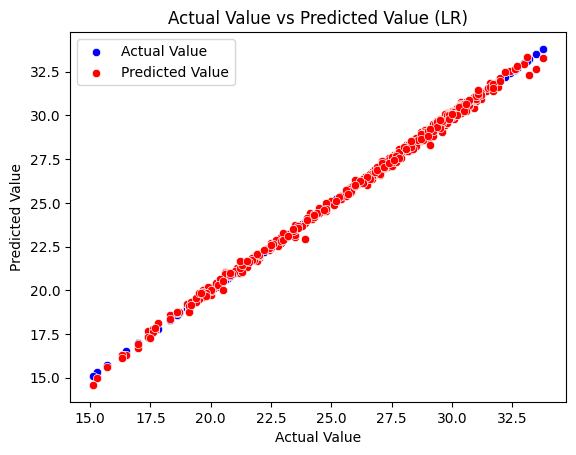

In [ ]:
sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (LR)')

plt.show()

In [ ]:
print('R squared for training            : {:.6f}'.format(mlr.score(x_train,y_train)))
print('R squared for testing             : {:.6f}'.format(mlr.score(x_test,y_test)))


R squared for training            : 0.997903
R squared for testing             : 0.998024


In [ ]:
#Model Evaluation
from sklearn import metrics
meanAbErr=metrics.mean_absolute_error(y_test,y_pred_mlr)
meanSqErr=metrics.mean_squared_error(y_test,y_pred_mlr)
rootMeanSqErr=np.sqrt(metrics.mean_squared_error(y_test,y_pred_mlr))
print('----------------------------MLR--------------------------------')
print('R-squared for Temperature in Dhaka           : {:.6f}'.format(mlr.score(x_t,y_t)))
print('Mean Absolute Error                          :',meanAbErr)
print('Mean Square Error                            :',meanSqErr)
print('Root Mean Square Error                       :',rootMeanSqErr)

----------------------------MLR--------------------------------
R-squared for Temperature in Dhaka           : 0.997943
Mean Absolute Error                          : 0.13409348982965813
Mean Square Error                            : 0.03257614617767373
Root Mean Square Error                       : 0.18048863171311852


In [ ]:
##########################################     Applying Ridge    ###################################
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_temp = Ridge()
params = {'alpha': [10000.0, 50000.0, 100000.0, 500000.0, 1000000.0 ]}


grid_ridge_temp = GridSearchCV(ridge_temp, param_grid=params, cv=7)
grid_ridge_temp.fit(x_train, y_train)
best_ridge_temp = grid_ridge_temp.best_estimator_

print(f'Best Ridge Regression Model for Temperature in Dhaka : {best_ridge_temp}')

Best Ridge Regression Model for Temperature in Dhaka : Ridge(alpha=10000.0)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_ridge = best_ridge_temp.predict(x_test)
mlr_dff1=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred_ridge})
mlr_dff1.head()

,Actual Value,Predicted Value
414,28.4,28.354057
509,28.9,28.643529
571,23.6,23.574277
28,31.6,31.777478
1681,21.2,21.057109


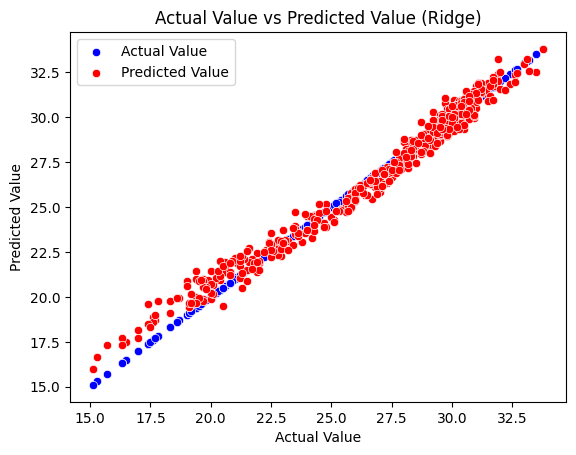

In [ ]:
sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff1, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff1, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Ridge)')

plt.show()

In [ ]:
#Evaluation

r2_ridge =metrics.r2_score(y_test, y_pred_ridge)
meanAbErr_ridge=metrics.mean_absolute_error(y_test,y_pred_ridge)
mse_ridge = metrics.mean_squared_error(y_test, y_pred_ridge)
meanSqErr_ridge=metrics.mean_squared_error(y_test,y_pred_ridge)
rootMeanSqErr_ridge=np.sqrt(metrics.mean_squared_error(y_test,y_pred_ridge))

print('----------------------------Ridge--------------------------------')
print(f'R-squared for Temperature in Dhaka           : {r2_ridge}')
print('Mean Absolute Error                          :',meanAbErr_ridge)
print('Mean Square Error                            :',mse_ridge)
print('Root Mean Square Error                       :',rootMeanSqErr_ridge)

----------------------------Ridge--------------------------------
R-squared for Temperature in Dhaka           : 0.9775720290859706
Mean Absolute Error                          : 0.47955591464133396
Mean Square Error                            : 0.36967933949795917
Root Mean Square Error                       : 0.6080126145878547


In [ ]:
##########################################     Applying Lasso   ###################################
from sklearn.linear_model import Lasso

lasso_temp = Lasso(max_iter=10000)
params = {'alpha': [7.0, 10.0, 15.0, 20.0,25.0]}

grid_lasso_temp = GridSearchCV(lasso_temp, param_grid=params, cv=7)
grid_lasso_temp.fit(x_train, y_train)
best_lasso_temp = grid_lasso_temp.best_estimator_


In [ ]:
cv_results = pd.DataFrame(grid_lasso_temp.cv_results_)
print(cv_results[['param_alpha', 'mean_test_score']])
print('')
print(f'Best Lasso Regression Model for Temperature in Dhaka: {best_lasso_temp}')

  param_alpha  mean_test_score
0         7.0         0.805214
1        10.0         0.663823
2        15.0         0.450034
3        20.0         0.433655
4        25.0         0.419630

Best Lasso Regression Model for Temperature in Dhaka: Lasso(alpha=7.0, max_iter=10000)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_lasso = best_lasso_temp.predict(x_test)
mlr_dff18=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred_lasso})
mlr_dff18.head()

,Actual Value,Predicted Value
414,28.4,27.106335
509,28.9,27.641265
571,23.6,23.408051
28,31.6,31.131519
1681,21.2,22.806913


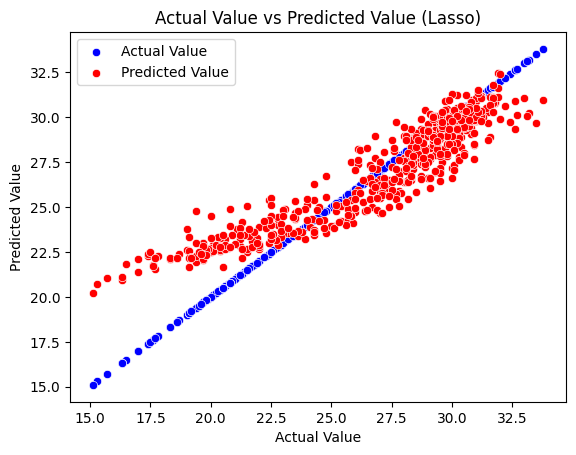

In [ ]:
sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff18, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff18, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Lasso)')

plt.show()

In [ ]:
#Evaluation
r2_lasso =metrics.r2_score(y_test, y_pred_lasso)
meanAbErr_lasso=metrics.mean_absolute_error(y_test,y_pred_lasso)
mse_lasso = metrics.mean_squared_error(y_test, y_pred_lasso)
meanSqErr_lasso=metrics.mean_squared_error(y_test,y_pred_lasso)
rootMeanSqErr_lasso=np.sqrt(metrics.mean_squared_error(y_test,y_pred_lasso))

print('----------------------------Lasso--------------------------------')
print(f'R-squared for Temperature in Dhaka           : {r2_lasso}')
print('Mean Absolute Error                          :',meanAbErr_lasso)
print('Mean Square Error                            :',mse_lasso)
print('Root Mean Square Error                       :',rootMeanSqErr_lasso)

----------------------------Lasso--------------------------------
R-squared for Temperature in Dhaka           : 0.8130131983334546
Mean Absolute Error                          : 1.3449555130671036
Mean Square Error                            : 3.0820959060404607
Root Mean Square Error                       : 1.755589902579888


In [ ]:
##########################################     Applying ElasticNet   ###################################
from sklearn.linear_model import ElasticNet


elasticnet_temp = ElasticNet(max_iter=10000)
params = {
    'alpha': [100.0, 1000.0,10000.0,],
    'l1_ratio': [0.0001, 0.0005, 0.0009]
}

grid_elasticnet_temp = GridSearchCV(elasticnet_temp, param_grid=params, cv=3)
grid_elasticnet_temp.fit(x_train, y_train)
best_elasticnet_temp = grid_elasticnet_temp.best_estimator_


print(f'Best ElasticNet Regression Model for Temperature in Dhaka: {best_elasticnet_temp}')

Best ElasticNet Regression Model for Temperature in Dhaka: ElasticNet(alpha=100.0, l1_ratio=0.0001, max_iter=10000)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_elasticnet = best_elasticnet_temp.predict(x_test)
mlr_dff2=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred_elasticnet})
mlr_dff2.head()

,Actual Value,Predicted Value
414,28.4,27.144089
509,28.9,27.948230
571,23.6,23.425949
28,31.6,30.504618
1681,21.2,22.920094


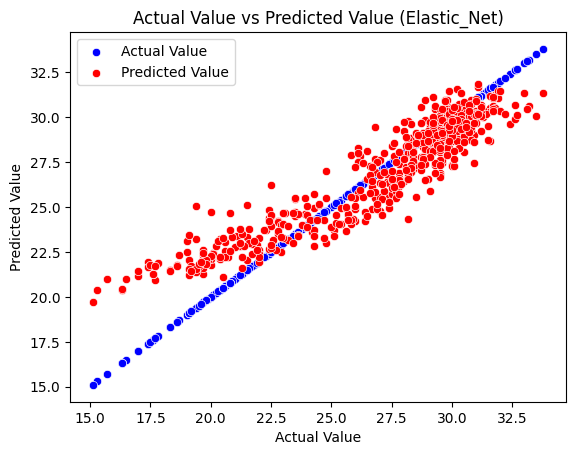

In [ ]:

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff2, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff2, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Elastic_Net)')

plt.show()

In [ ]:
#Evaluation
r2_elasticnet = metrics.r2_score(y_test, y_pred_elasticnet)
meanAbErr_elasticnet=metrics.mean_absolute_error(y_test,y_pred_elasticnet)
mse_elasticnet = metrics.mean_squared_error(y_test, y_pred_elasticnet)
meanSqErr_elasticnet=metrics.mean_squared_error(y_test,y_pred_elasticnet)
rootMeanSqErr_elasticnet=np.sqrt(metrics.mean_squared_error(y_test,y_pred_elasticnet))

print('----------------------------ElasticNet--------------------------------')
print(f'R-squared for Temperature in Dhaka           : {r2_elasticnet}')
print('Mean Absolute Error                          :',meanAbErr_elasticnet)
print('Mean Square Error                            :',mse_elasticnet)
print('Root Mean Square Error                       :',rootMeanSqErr_elasticnet)

----------------------------ElasticNet--------------------------------
R-squared for Temperature in Dhaka           : 0.8352057616885794
Mean Absolute Error                          : 1.2960163338970878
Mean Square Error                            : 2.716296779836083
Root Mean Square Error                       : 1.648119164331294


In [ ]:
##########################################     Applying Random Forest   ###################################
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [5, 10],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [1, 2],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_temp = RandomForestRegressor(random_state=42)
grid_search_temp_dhaka = GridSearchCV(estimator=rf_temp, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search_temp_dhaka.fit(x_train, y_train)

best_rf_temp = grid_search_temp_dhaka.best_estimator_
print(f'Best Random Forest Model for Temperature in Dhaka : {best_rf_temp}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Random Forest Model for Temperature in Dhaka : RandomForestRegressor(max_depth=2, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=5, random_state=42)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_rf = best_rf_temp.predict(x_test)
mlr_dff3=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred_rf})
mlr_dff3.head()

,Actual Value,Predicted Value
414,28.4,29.530034
509,28.9,29.069536
571,23.6,22.964290
28,31.6,30.062235
1681,21.2,22.065439


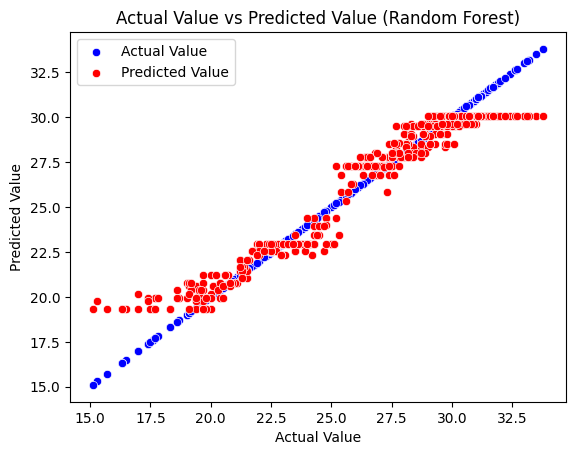

In [ ]:
sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff3, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff3, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Random Forest)')

plt.show()

In [ ]:
#Evaluation
r2_rf = metrics.r2_score(y_test, y_pred_rf)
meanAbErr_rf=metrics.mean_absolute_error(y_test,y_pred_rf)
mse_rf = metrics.mean_squared_error(y_test, y_pred_rf)
meanSqErr_rf=metrics.mean_squared_error(y_test,y_pred_rf)
rootMeanSqErr_rf=np.sqrt(metrics.mean_squared_error(y_test,y_pred_rf))

print('----------------------------Random Forest--------------------------------')
print(f'R-squared for Temperature in Dhaka            : {r2_rf}')
print('Mean Absolute Error                          :',meanAbErr_rf)
print('Mean Square Error                            :',mse_rf)
print('Root Mean Square Error                       :',rootMeanSqErr_rf)

----------------------------Random Forest--------------------------------
R-squared for Temperature in Dhaka            : 0.9394479192876918
Mean Absolute Error                          : 0.746904397158875
Mean Square Error                            : 0.9980775028092647
Root Mean Square Error                       : 0.9990382889605707


In [ ]:
                  ###################################For Rainfall######################################


In [ ]:
#Setting value for X and Y
x_rain=dhaka[['month','tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike','dew', 'humidity','precipprob','precipcover', 'preciptype','windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']]
y_rain=dhaka['precip']

In [ ]:
#Splitting the data set
from sklearn.model_selection import train_test_split
x_train_rain,x_test_rain,y_train_rain,y_test_rain=train_test_split(x_rain,y_rain,test_size=0.3,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
mlr_rain=LinearRegression()
mlr_rain.fit(x_train_rain, y_train_rain)

LinearRegression()

In [ ]:
#intercept and Coefficient
print("Intercept: ",mlr_rain.intercept_)
print("Coefficients: ")
list(zip(x_rain,mlr_rain.coef_))

Intercept:  -55.87490606387915
Coefficients: 


[('month', 0.13145206325401662),
 ('tempmax', -0.17067783046822557),
 ('tempmin', -0.9074903346127562),
 ('temp', 4.923115420270193),
 ('feelslikemax', 0.13437134897972772),
 ('feelslikemin', 0.2665138280037753),
 ('feelslike', -1.2886633986367009),
 ('dew', -2.588525713344882),
 ('humidity', 0.7253596473870237),
 ('precipprob', -0.025666619223641576),
 ('precipcover', 0.22128522456757635),
 ('preciptype', -0.00025666619223249274),
 ('windgust', 0.1396777134069619),
 ('windspeed', 0.09697816070751948),
 ('winddir', -0.001530636818013898),
 ('sealevelpressure', -0.016644230459333356),
 ('cloudcover', 0.011066016075849363),
 ('visibility', -1.3720092912722766),
 ('solarradiation', 0.16962879000584413),
 ('solarenergy', -2.31989368244286),
 ('uvindex', 0.22501462324970717)]

In [ ]:
#Prediction of test set
y_pred_rain=mlr_rain.predict(x_test_rain)

In [ ]:
#Actual value & the predicted value for Training data set
rain_df=pd.DataFrame({'Actual Value': y_test_rain,'Predicted Value': y_pred_rain})
rain_df.head()

,Actual Value,Predicted Value
247,4.7,12.901449
1293,0.0,-0.493567
1562,10.0,11.454613
1101,8.2,7.230508
1161,1.5,-0.792105


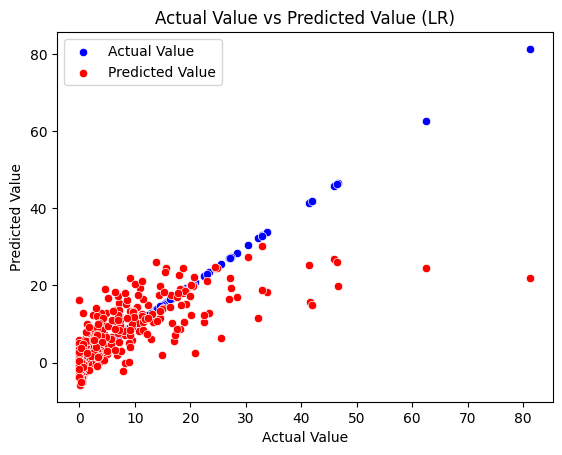

In [ ]:

sns.scatterplot(x='Actual Value', y='Actual Value', data=rain_df, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=rain_df, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (LR)')

plt.show()

In [ ]:
print('R squared for training            : {:.6f}'.format(mlr_rain.score(x_train_rain,y_train_rain)))
print('R squared for testing             : {:.6f}'.format(mlr_rain.score(x_test_rain,y_test_rain)))

R squared for training            : 0.555145
R squared for testing             : 0.586410


In [ ]:
#Model Evaluation
from sklearn import metrics
meanAbErr_rain=metrics.mean_absolute_error(y_test_rain,y_pred_rain)
meanSqErr_rain=metrics.mean_squared_error(y_test_rain,y_pred_rain)
rootMeanSqErr_rain=np.sqrt(metrics.mean_squared_error(y_test_rain,y_pred_rain))
print('----------------MLR------------------------------------------------')
print('R squared              : {:.6f}'.format(mlr_rain.score(x_rain,y_rain)))
print('Mean Absolute Error    :',meanAbErr_rain)
print('Mean Square Error      :',meanSqErr_rain)
print('Root Mean Square Error :',rootMeanSqErr_rain)

R squared              : 0.563067
Mean Absolute Error    : 3.1098283422245654
Mean Square Error      : 31.419202298356026
Root Mean Square Error : 5.605283427120883


In [ ]:
##########################################     Applying Ridge    ###################################

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


ridge_rain = Ridge()
params = {'alpha': [0.00001, 0.0000001, 0.000000001]}

grid_ridge_rain = GridSearchCV(ridge_rain, param_grid=params, cv=7)
grid_ridge_rain.fit(x_train_rain, y_train_rain)
best_ridge = grid_ridge_rain.best_estimator_

print(f'Best Ridge Regression Model for Precipitation in Dhaka : {best_ridge}')


Best Ridge Regression Model for Precipitation in Dhaka : Ridge(alpha=1e-05)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.40339e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.25679e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.4007e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.43564e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning

In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_rain_ridge = best_ridge.predict(x_test_rain)
mlr_dff11=pd.DataFrame({'Actual Value': y_test_rain,'Predicted Value':y_pred_rain_ridge})
mlr_dff11.head()

,Actual Value,Predicted Value
247,4.7,12.901449
1293,0.0,-0.493567
1562,10.0,11.454613
1101,8.2,7.230508
1161,1.5,-0.792105


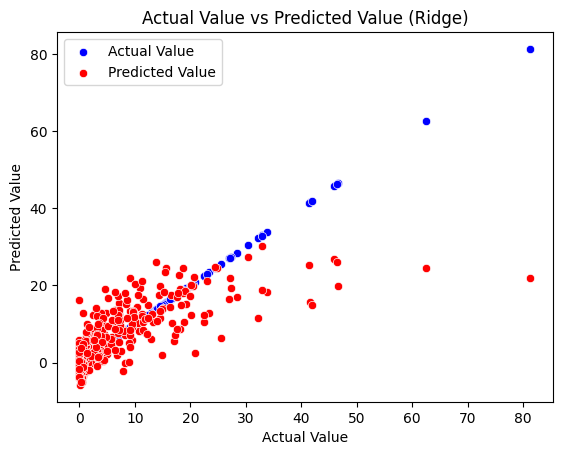

In [ ]:

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff11, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff11, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Ridge)')

plt.show()

In [ ]:
#Evaluation
r2_rain_ridge = metrics.r2_score(y_test_rain, y_pred_rain_ridge)
meanAbErr_rain_ridge=metrics.mean_absolute_error(y_test_rain,y_pred_rain_ridge)
mse_rain_ridge = metrics.mean_squared_error(y_test_rain, y_pred_rain_ridge)
meanSqErr_rain_ridge=metrics.mean_squared_error(y_test_rain,y_pred_rain_ridge)
rootMeanSqErr_rain_ridge=np.sqrt(metrics.mean_squared_error(y_test_rain,y_pred_rain_ridge))

print('----------------------------Ridge--------------------------------')
print(f'R-squared for Rainfall in Dhaka              : {r2_rain_ridge}')
print('Mean Absolute Error                          :',meanAbErr_rain_ridge)
print('Mean Square Error                            :',mse_rain_ridge)
print('Root Mean Square Error                       :',rootMeanSqErr_rain_ridge)


----------------------------Ridge--------------------------------
R-squared for Rainfall in Dhaka              : 0.5864098594779029
Mean Absolute Error                          : 3.1098282750598156
Mean Square Error                            : 31.41920178376892
Root Mean Square Error                       : 5.6052833812189125


In [ ]:
##########################################     Applying ElasticNet   ###################################
from sklearn.linear_model import ElasticNet


elasticnet_rain = ElasticNet(max_iter=500000)
params = {
    'alpha': [0.00001, 0.000001, 0.0000001],
    'l1_ratio': [0.001, 0.005, 0.009]
}

grid_elasticnet_rain = GridSearchCV(elasticnet_rain, param_grid=params, cv=3)
grid_elasticnet_rain.fit(x_train_rain, y_train_rain)
best_elasticnet_rain = grid_elasticnet_rain.best_estimator_


print(f'Best ElasticNet Regression Model for Rainfall in Dhaka: {best_elasticnet_rain}')



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.974e+04, tolerance: 8.503e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.247e+04, tolerance: 6.366e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.118e+04, tolerance: 9.742e

Best ElasticNet Regression Model for Rainfall in Dhaka: ElasticNet(alpha=1e-05, l1_ratio=0.001, max_iter=500000)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_elasticnet_r = best_elasticnet_rain.predict(x_test_rain)
mlr_dff2=pd.DataFrame({'Actual Value': y_test_rain,'Predicted Value': y_pred_elasticnet_r})
mlr_dff2.head()

,Actual Value,Predicted Value
247,4.7,12.900711
1293,0.0,-0.493445
1562,10.0,11.454721
1101,8.2,7.230779
1161,1.5,-0.792061


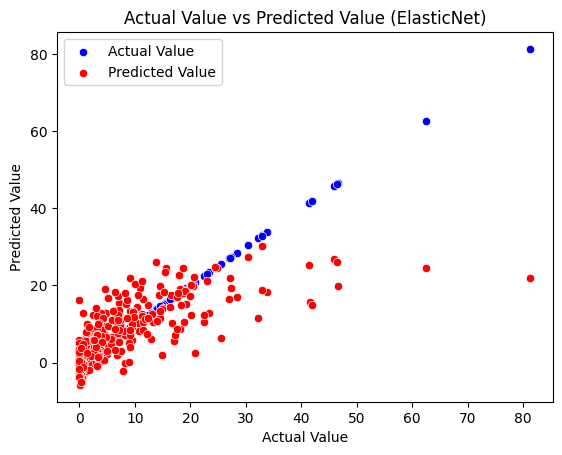

In [ ]:

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff2, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff2, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (ElasticNet)')

plt.show()

In [ ]:
#Evaluation
r2_elasticnet1 = metrics.r2_score(y_test_rain, y_pred_elasticnet_r)
meanAbErr_elasticnet1=metrics.mean_absolute_error(y_test_rain,y_pred_elasticnet_r)
mse_elasticnet1 =metrics.mean_squared_error(y_test_rain, y_pred_elasticnet_r)
meanSqErr_elasticnet1=metrics.mean_squared_error(y_test_rain,y_pred_elasticnet_r)
rootMeanSqErr_elasticnet1=np.sqrt(metrics.mean_squared_error(y_test_rain,y_pred_elasticnet_r))

print('----------------------------ElasticNet--------------------------------')
print(f'R-squared for Temperature in Dhaka           : {r2_elasticnet1}')
print('Mean Absolute Error                          :',meanAbErr_elasticnet1)
print('Mean Square Error                            :',mse_elasticnet1)
print('Root Mean Square Error                       :',rootMeanSqErr_elasticnet1)


----------------------------ElasticNet--------------------------------
R-squared for Temperature in Dhaka           : 0.586418476704084
Mean Absolute Error                          : 3.109742532843772
Mean Square Error                            : 31.4185471589564
Root Mean Square Error                       : 5.605224987362809


In [ ]:
##########################  Applying Random Forest########################
rf_regressor = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [10, 20, 50],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf_regressor = GridSearchCV(rf_regressor, param_grid=params, cv=5, n_jobs=-1, verbose=2)
grid_rf_regressor.fit(x_train_rain, y_train_rain)
best_rf = grid_rf_regressor.best_estimator_

print(f'Best Random Forest Regression Model for Rainfall in Dhaka : {best_rf}')



Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Regression Model for Rainfall in Dhaka : RandomForestRegressor(max_depth=20, min_samples_leaf=4, n_estimators=50,
                      random_state=42)


In [ ]:
#Actual value & the predicted value for Testing data set
y_pred_rain_r = best_rf.predict(x_test_rain)
mlr_dff21=pd.DataFrame({'Actual Value': y_test_rain,'Predicted Value': y_pred_rain_r})
mlr_dff21.head()


,Actual Value,Predicted Value
247,4.7,9.621191
1293,0.0,0.000000
1562,10.0,12.087726
1101,8.2,11.100230
1161,1.5,1.050843


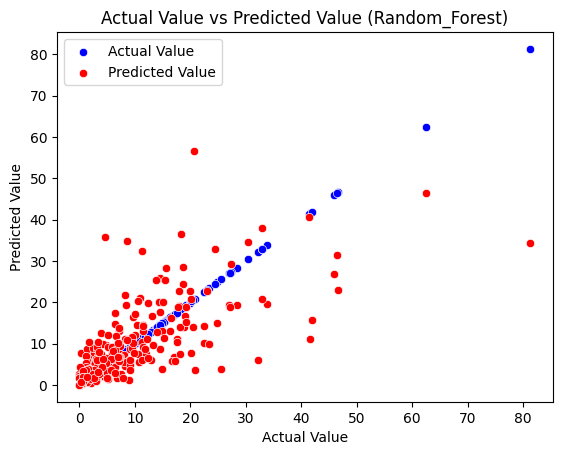

In [ ]:
sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff21, color='blue', label='Actual Value')

sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff21, color='red', label='Predicted Value')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value vs Predicted Value (Random_Forest)')

plt.show()

In [ ]:
#Evaluation
r2_rf_r = metrics.r2_score(y_test_rain, y_pred_rain_r )
meanAbErr_rf_r=metrics.mean_absolute_error( y_test_rain,y_pred_rain_r )
mse_rf_r = metrics.mean_squared_error(y_test_rain, y_pred_rain_r )
meanSqErr_rf_r=metrics.mean_squared_error( y_test_rain,y_pred_rain_r )
rootMeanSqErr_rf_r=np.sqrt(metrics.mean_squared_error( y_test_rain,y_pred_rain_r ))

print('----------------------------Random Forest--------------------------------')
print(f'R-squared for Temperature in Dhaka           : {r2_rf_r}')
print('Mean Absolute Error                          :',meanAbErr_rf_r)
print('Mean Square Error                            :',mse_rf_r)
print('Root Mean Square Error                       :',rootMeanSqErr_rf_r)


----------------------------Random Forest--------------------------------
R-squared for Temperature in Dhaka           : 0.6166679118697125
Mean Absolute Error                          : 2.2887617922195775
Mean Square Error                            : 29.120588348540462
Root Mean Square Error                       : 5.396349539136661


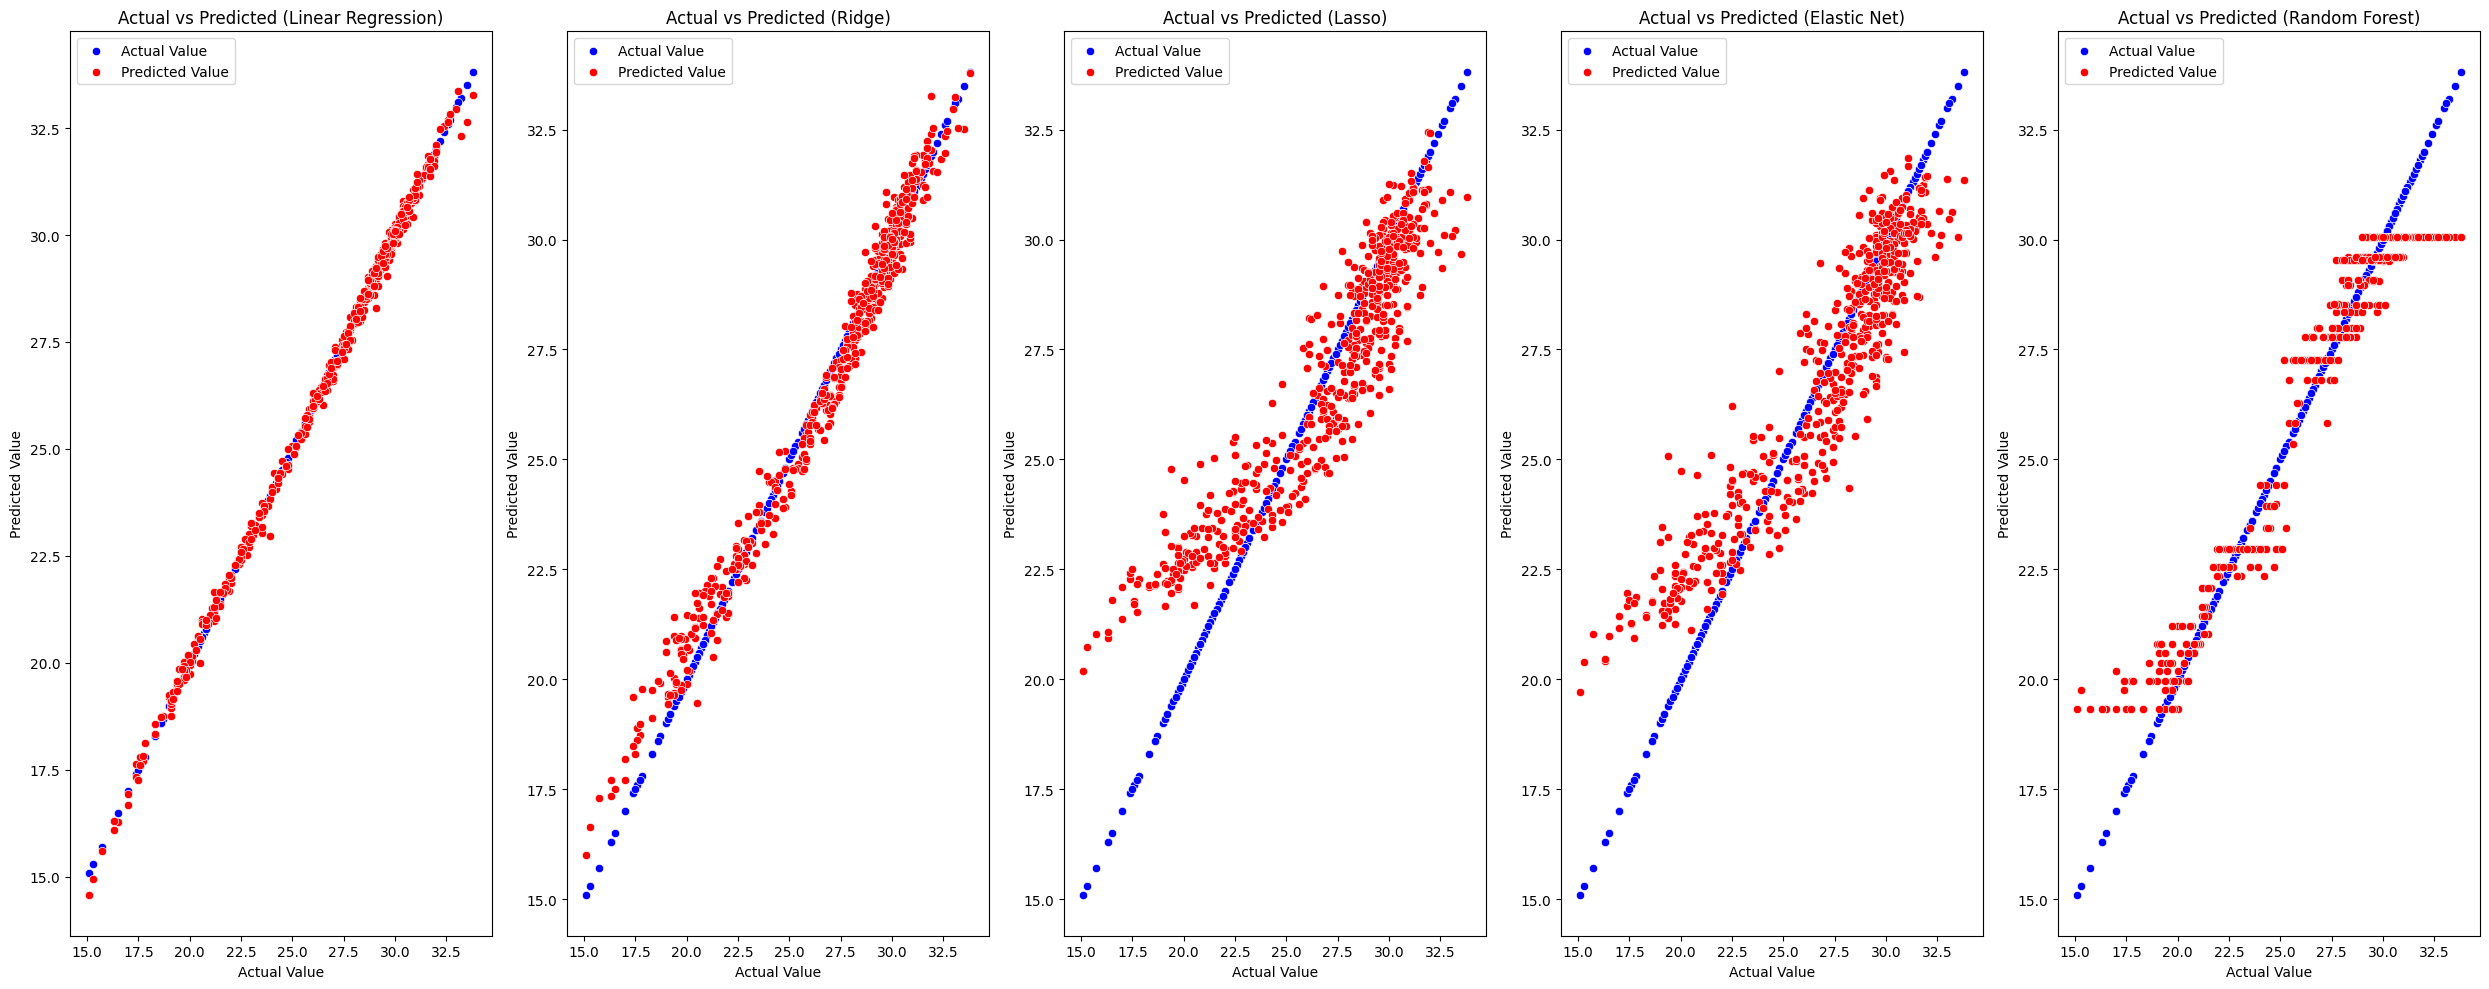

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(25, 10))

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff, color='blue', label='Actual Value', ax=axs[0])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff, color='red', label='Predicted Value', ax=axs[0])
axs[0].set_xlabel('Actual Value')
axs[0].set_ylabel('Predicted Value')
axs[0].set_title('Actual vs Predicted (Linear Regression)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff1, color='blue', label='Actual Value', ax=axs[1])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff1, color='red', label='Predicted Value', ax=axs[1])
axs[1].set_xlabel('Actual Value')
axs[1].set_ylabel('Predicted Value')
axs[1].set_title('Actual vs Predicted (Ridge)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff18, color='blue', label='Actual Value', ax=axs[2])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff18, color='red', label='Predicted Value', ax=axs[2])
axs[2].set_xlabel('Actual Value')
axs[2].set_ylabel('Predicted Value')
axs[2].set_title('Actual vs Predicted (Lasso)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff2, color='blue', label='Actual Value', ax=axs[3])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff2, color='red', label='Predicted Value', ax=axs[3])
axs[3].set_xlabel('Actual Value')
axs[3].set_ylabel('Predicted Value')
axs[3].set_title('Actual vs Predicted (Elastic Net)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff3, color='blue', label='Actual Value', ax=axs[4])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff3, color='red', label='Predicted Value', ax=axs[4])
axs[4].set_xlabel('Actual Value')
axs[4].set_ylabel('Predicted Value')
axs[4].set_title('Actual vs Predicted (Random Forest)')


plt.tight_layout()


plt.show()


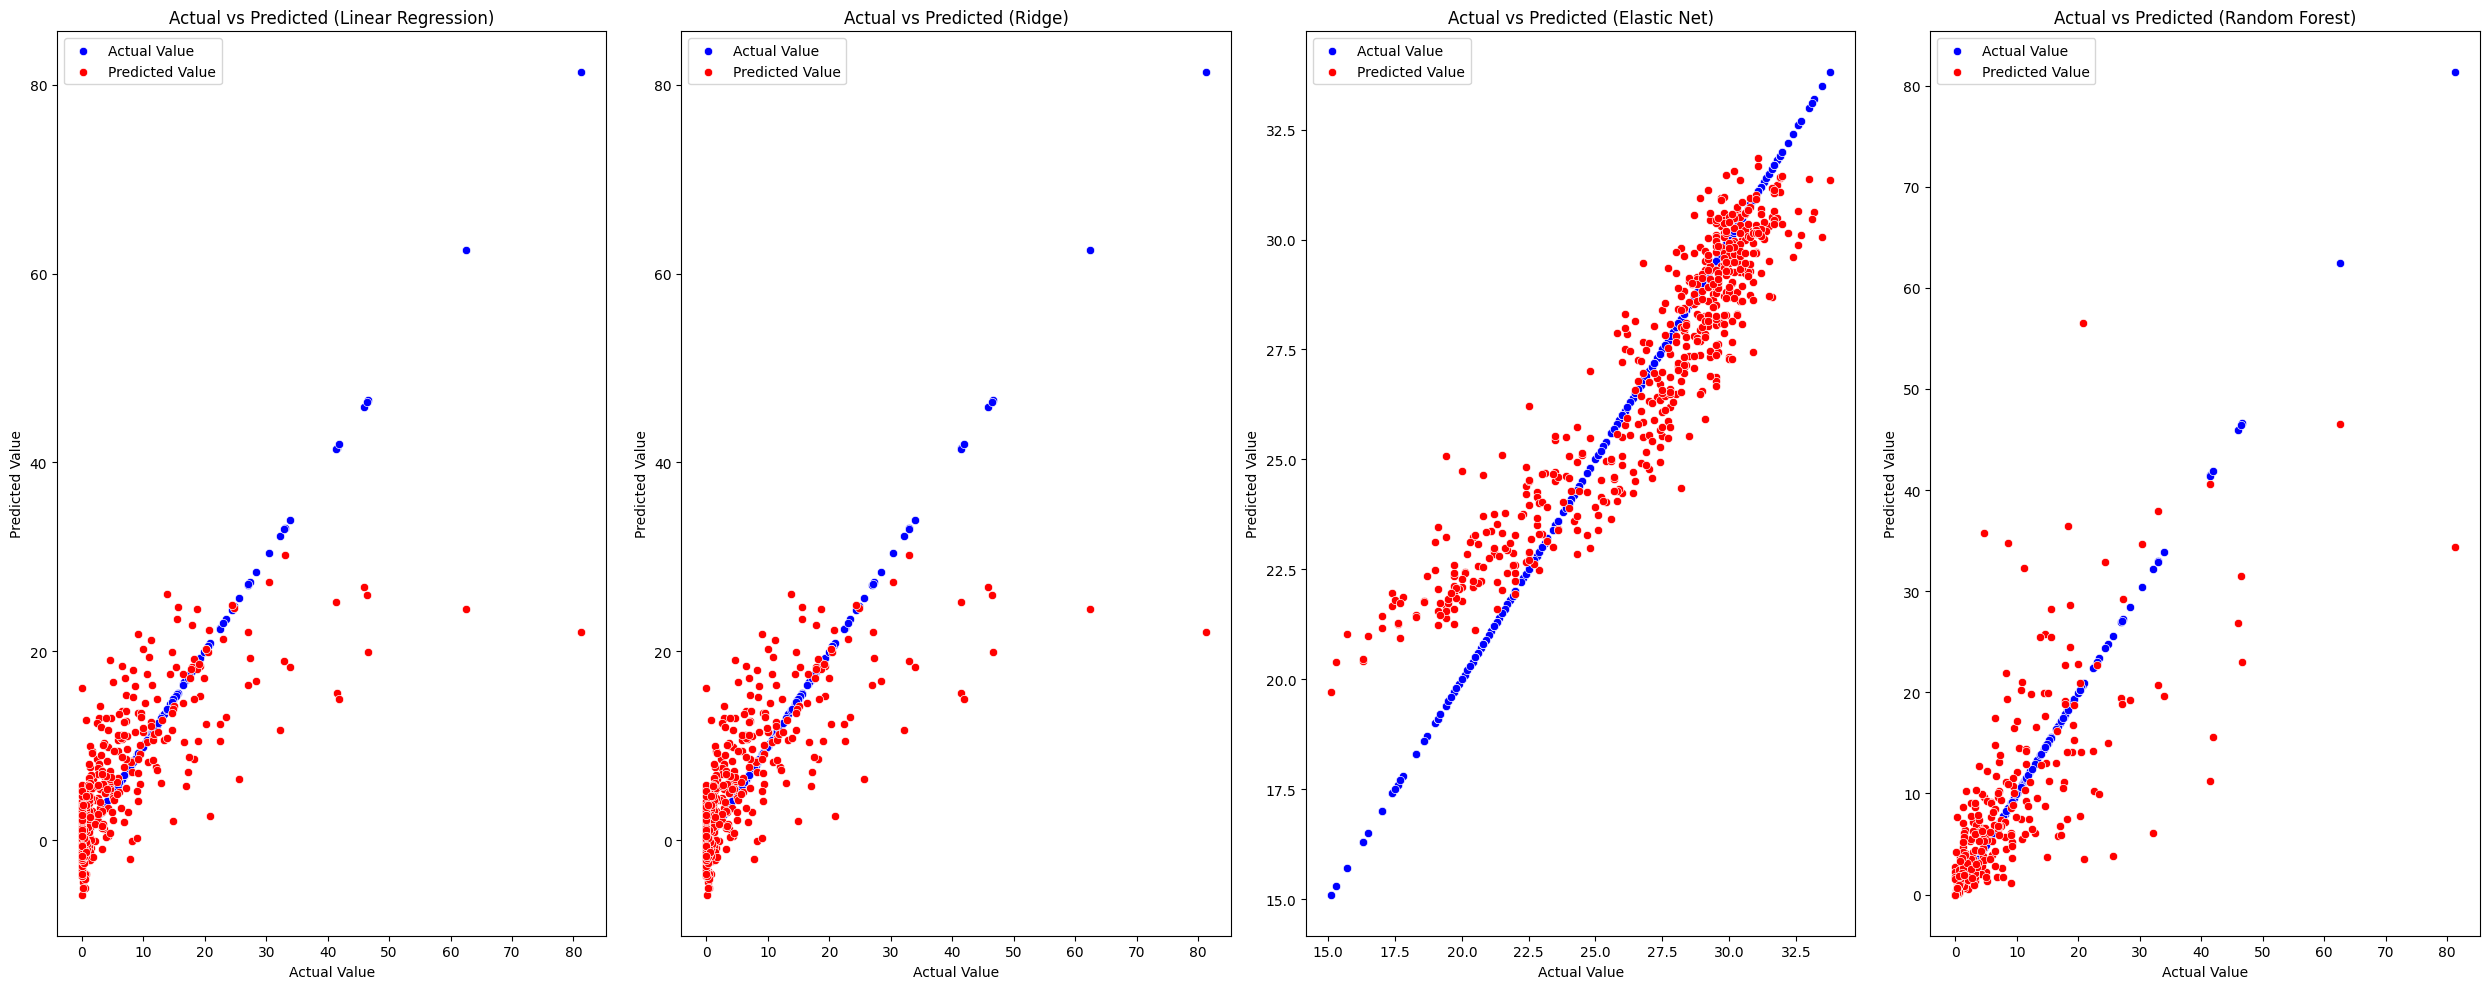

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(25, 10))

sns.scatterplot(x='Actual Value', y='Actual Value', data=rain_df, color='blue', label='Actual Value', ax=axs[0])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=rain_df, color='red', label='Predicted Value', ax=axs[0])
axs[0].set_xlabel('Actual Value')
axs[0].set_ylabel('Predicted Value')
axs[0].set_title('Actual vs Predicted (Linear Regression)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff11, color='blue', label='Actual Value', ax=axs[1])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff11, color='red', label='Predicted Value', ax=axs[1])
axs[1].set_xlabel('Actual Value')
axs[1].set_ylabel('Predicted Value')
axs[1].set_title('Actual vs Predicted (Ridge)')


sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff2, color='blue', label='Actual Value', ax=axs[2])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff2, color='red', label='Predicted Value', ax=axs[2])
axs[2].set_xlabel('Actual Value')
axs[2].set_ylabel('Predicted Value')
axs[2].set_title('Actual vs Predicted (Elastic Net)')

sns.scatterplot(x='Actual Value', y='Actual Value', data=mlr_dff21, color='blue', label='Actual Value', ax=axs[3])
sns.scatterplot(x='Actual Value', y='Predicted Value', data=mlr_dff21, color='red', label='Predicted Value', ax=axs[3])
axs[3].set_xlabel('Actual Value')
axs[3].set_ylabel('Predicted Value')
axs[3].set_title('Actual vs Predicted (Random Forest)')


plt.tight_layout()


plt.show()


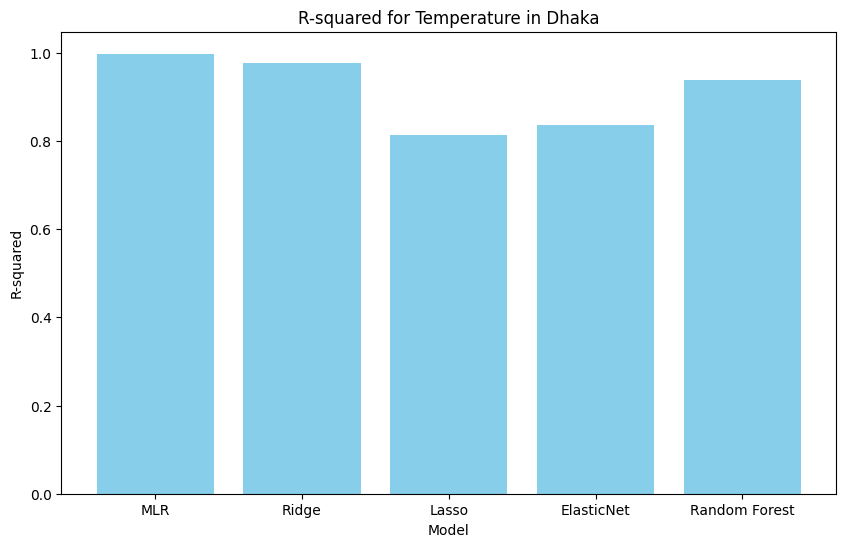

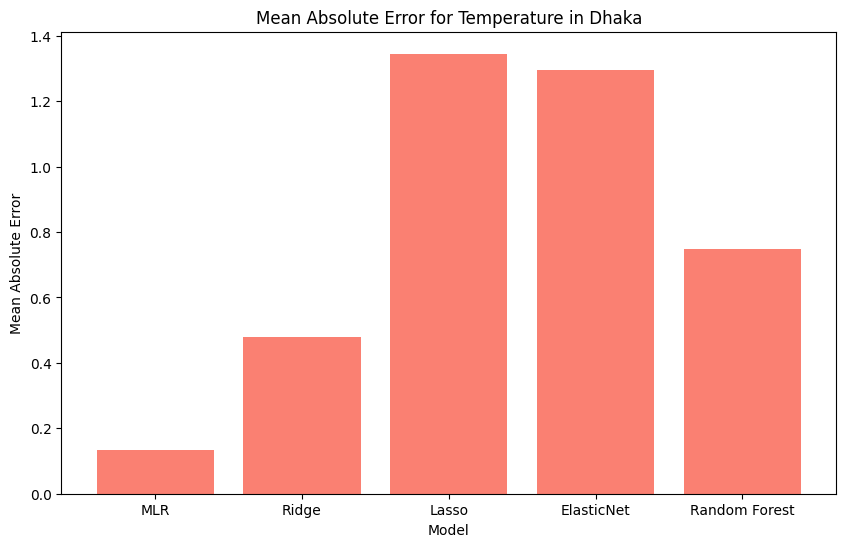

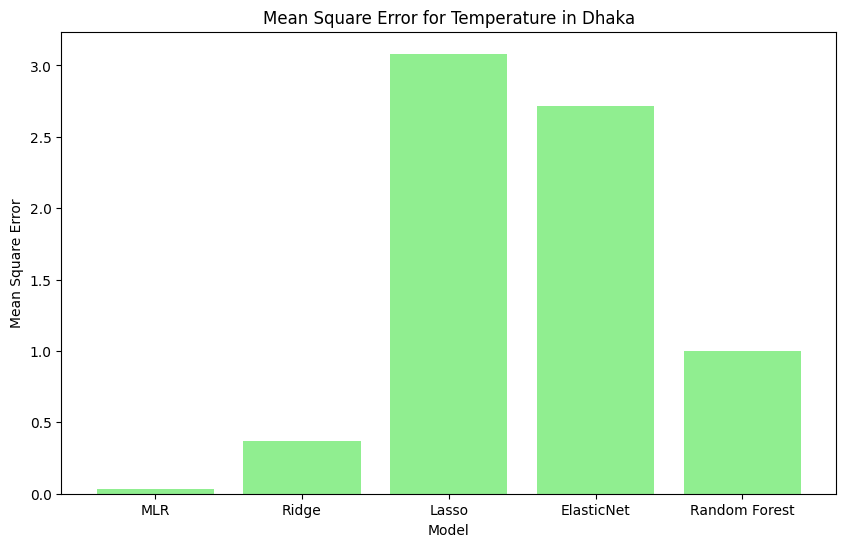

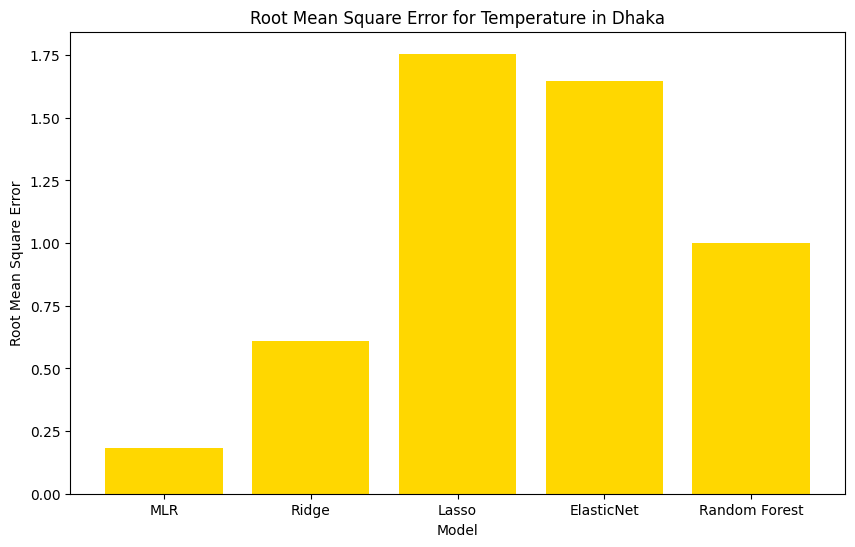

In [ ]:
import matplotlib.pyplot as plt


models = ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest']
r_squared = [0.997943, 0.977572, 0.813013, 0.835206, 0.939448]
mean_absolute_error = [0.134093, 0.479556, 1.344956, 1.296016, 0.746904]
mean_square_error = [0.032576, 0.369679, 3.082096, 2.716297, 0.998078]
root_mean_square_error = [0.180489, 0.608013, 1.755590, 1.648119, 0.999038]


plt.figure(figsize=(10, 6))
plt.bar(models, r_squared, color='skyblue')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.title('R-squared for Temperature in Dhaka')
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(models, mean_absolute_error, color='salmon')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error for Temperature in Dhaka')
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(models, mean_square_error, color='lightgreen')
plt.xlabel('Model')
plt.ylabel('Mean Square Error')
plt.title('Mean Square Error for Temperature in Dhaka')
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, root_mean_square_error, color='gold')
plt.xlabel('Model')
plt.ylabel('Root Mean Square Error')
plt.title('Root Mean Square Error for Temperature in Dhaka')
plt.show()


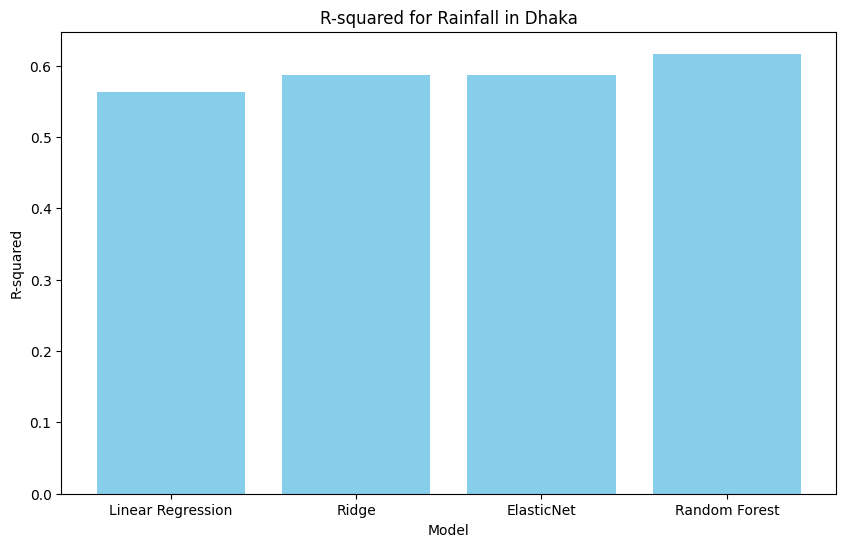

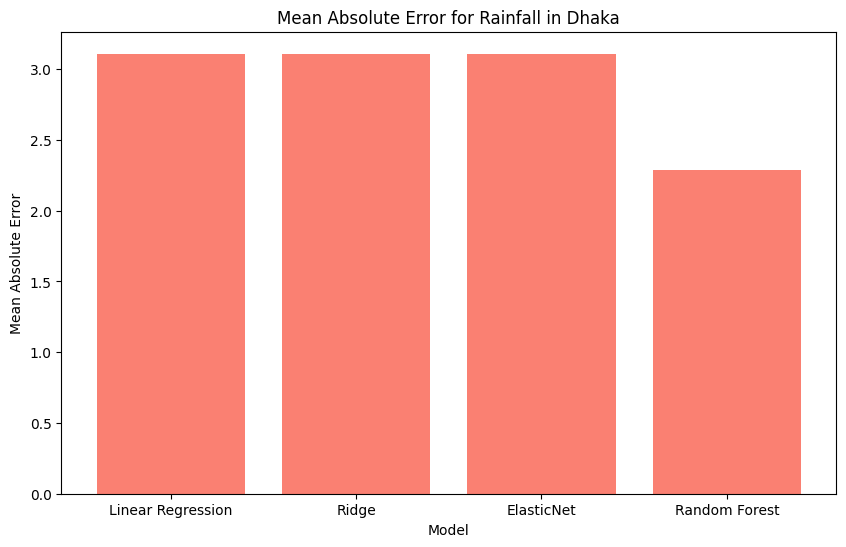

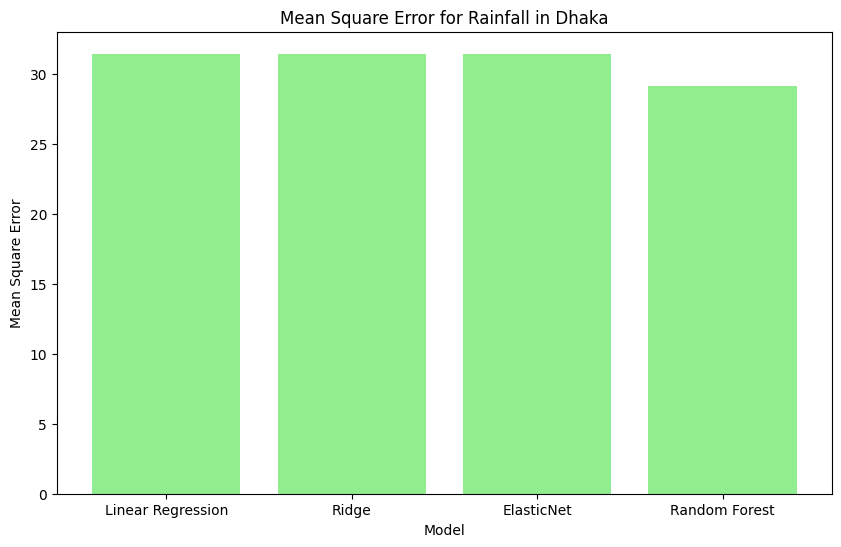

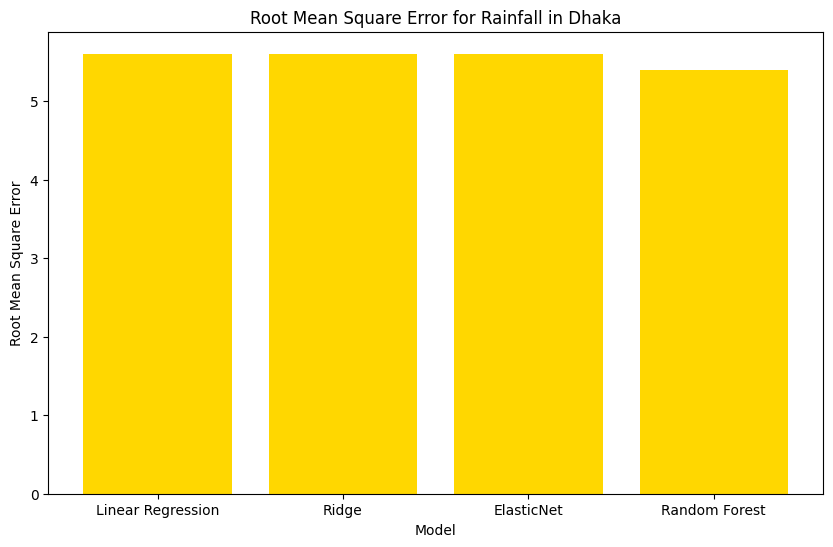

In [ ]:
import matplotlib.pyplot as plt

# Data for different models
models = ['Linear Regression', 'Ridge', 'ElasticNet', 'Random Forest']
r_squared = [0.563067, 0.586409, 0.586418, 0.616668]
mean_absolute_error = [3.109828, 3.109828, 3.109743, 2.288762]
mean_square_error = [31.419202, 31.419202, 31.418547, 29.120588]
root_mean_square_error = [5.605283, 5.605283, 5.605225, 5.396350]

# Plotting R-squared values
plt.figure(figsize=(10, 6))
plt.bar(models, r_squared, color='skyblue')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.title('R-squared for Rainfall in Dhaka')
plt.show()

# Plotting Mean Absolute Error
plt.figure(figsize=(10, 6))
plt.bar(models, mean_absolute_error, color='salmon')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error for Rainfall in Dhaka')
plt.show()

# Plotting Mean Square Error
plt.figure(figsize=(10, 6))
plt.bar(models, mean_square_error, color='lightgreen')
plt.xlabel('Model')
plt.ylabel('Mean Square Error')
plt.title('Mean Square Error for Rainfall in Dhaka')
plt.show()

# Plotting Root Mean Square Error
plt.figure(figsize=(10, 6))
plt.bar(models, root_mean_square_error, color='gold')
plt.xlabel('Model')
plt.ylabel('Root Mean Square Error')
plt.title('Root Mean Square Error for Rainfall in Dhaka')
plt.show()
